# 03 – Severity GLM (Gamma)
Fit a Gamma GLM for average claim severity on claim records.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.insert(0, "../src")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
%matplotlib inline


In [2]:
from glm_pricing.data import load_freq
from glm_pricing.preprocessing import cap_exposure, cap_claimnb, prepare_features, train_test_split_policy
from glm_pricing.models import fit_severity
from glm_pricing.evaluation import gamma_deviance, lift_chart
import numpy as np

df = load_freq("../data/sample/freMTPL_sample.csv")
df = cap_exposure(df)
df = cap_claimnb(df)
df = prepare_features(df)
train, test = train_test_split_policy(df)

print(f"Train claims: {(train['ClaimNb'].astype(float)>0).sum()}")
print(f"Test  claims: {(test['ClaimNb'].astype(float)>0).sum()}")


Train claims: 204
Test  claims: 47


In [3]:
SEV_FEATURES = ["BonusMalusCapped", "LogDensity", "VehPower", "VehGas", "Area"]
sev_model = fit_severity(train, SEV_FEATURES)
print(sev_model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:               AvgClaim   No. Observations:                  150
Model:                            GLM   Df Residuals:                      146
Model Family:                   Gamma   Df Model:                            9
Link Function:                    Log   Scale:                         0.97641
Method:                          IRLS   Log-Likelihood:                -1282.3
Date:                Sat, 23 May 2026   Deviance:                       116.57
Time:                        02:00:50   Pearson chi2:                     143.
No. Iterations:                    17   Pseudo R-squ. (CS):            0.07216
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               8.3057    

In [4]:
# Evaluate on test claims
test_claims = test[(test["ClaimNb"].astype(float) > 0) & (test["ClaimAmountTotal"] > 0)].copy()
test_claims["AvgClaim"] = test_claims["ClaimAmountTotal"] / test_claims["ClaimNb"].astype(float)
sev_pred_test = sev_model.predict(test_claims)

gam_dev = gamma_deviance(test_claims["AvgClaim"].values, sev_pred_test.values, weights=test_claims["ClaimNb"].astype(float).values)
print(f"Gamma Deviance (test): {gam_dev:.6f}")
print(f"Mean predicted severity: {sev_pred_test.mean():.2f}")
print(f"Mean actual   severity: {test_claims['AvgClaim'].mean():.2f}")


Gamma Deviance (test): 1.220318
Mean predicted severity: 1305.99
Mean actual   severity: 1242.47


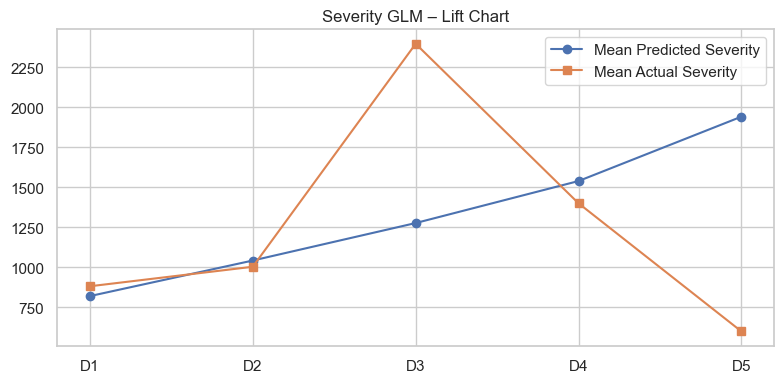

Severity GLM complete.


In [5]:
# Lift chart for severity
if len(test_claims) >= 5:
    n_bins = min(5, len(test_claims) // 2)
    lc = lift_chart(test_claims["AvgClaim"].values, sev_pred_test.values, n_bins=n_bins)
    fig, ax = plt.subplots(figsize=(8, 4))
    x = range(len(lc))
    ax.plot(x, lc["mean_pred"], marker="o", label="Mean Predicted Severity")
    ax.plot(x, lc["mean_actual"], marker="s", label="Mean Actual Severity")
    ax.set_xticks(x)
    ax.set_xticklabels([f"D{i+1}" for i in x])
    ax.set_title("Severity GLM – Lift Chart")
    ax.legend()
    plt.tight_layout()
    plt.savefig("../data/sample/sev_lift_chart.png", dpi=80)
    plt.show()
print("Severity GLM complete.")
